In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score

Matplotlib is building the font cache; this may take a moment.


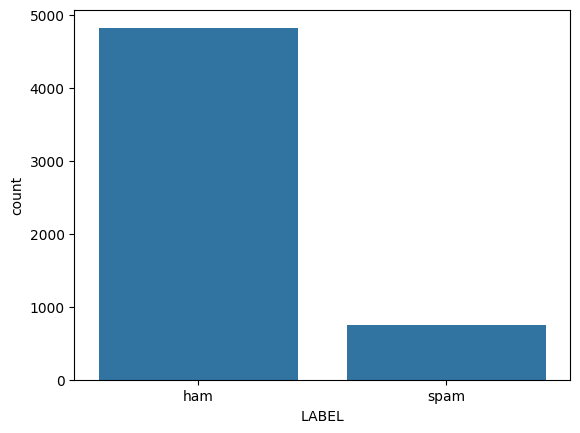

In [2]:
messages = pd.read_csv('EmailCollection', sep='\t', names=['LABEL', 'MESSAGES'])

import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='LABEL', data=messages)
plt.show()

In [3]:
import nltk
import re
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...


KeyboardInterrupt: 

In [ ]:
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer=WordNetLemmatizer() 
corpus = []
for i in range(0, len(messages)):

    review = re.sub('[^a-zA-Z]', ' ', messages['MESSAGES'][i])
   
    review = review.lower()
  
    review = review.split()
  
    review = [stemmer.stem(word) for word in review if not word in stopwords.words('english')]
   
    review = ' '.join(review)
    corpus.append(review)
print(corpus)

In [ ]:

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features = 3500)
X = cv.fit_transform(corpus).toarray()

y = pd.get_dummies(messages['LABEL'])
y = y.iloc[:, 1].values

Pickle File Adding

In [ ]:
##import pickle
# Creating a pickle file for the CountVectorizer
##pickle.dump(cv, open('cv-transform.pkl', 'wb'))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)


print("X_train",X_train)
print("X_test",X_test)


In [ ]:

from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB(alpha=0.8)
mnb.fit(X_train,y_train)
y_pred_mnb=mnb.predict(X_test)
mnb_acc = accuracy_score(y_pred_mnb,y_test)
print("MNB Accuracy",mnb_acc)




In [ ]:
message="WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only"
data = [message]
vect = cv.transform(data).toarray()
my_prediction = mnb.predict(vect)
if my_prediction==0:
    print("It's a Ham Mail")
else:
    print("It's a Spam Mail")


In [ ]:

    
# Creating a pickle file for the Multinomial Naive Bayes model
##filename = 'model.pkl'
##pickle.dump(mnb, open(filename, 'wb'))
